In [8]:
# Extract, transform, load.
import yfinance as yf
import pandas as pd


# -------EXTRACT----

# Dow 30 composition in 2003
dow_2003 = [
    "MMM", "AA", "MO", "AXP", "T",
    "BA", "CAT", "C", "KO", "DD", 
    "EK", "XOM", "GE", "GM", "HPQ", 
    "HD", "HON", "INTC", "IBM", "IP", 
    "JNJ", "JPM", "MCD", "MRK", "MSFT", 
    "PG", "SBC", "UTX", "WMT", "DIS"
]

def get_dow_forward_history():
    # Historical changes from 2003 to present
    forward_steps = {
        2004: {"remove": ["T", "EK", "IP"], "add": ["AIG", "PFE", "VZ"]},
        2005: {"remove": ["SBC"], "add": ["T"]},
        2008: {"remove": ["AIG", "MO", "HON"], "add": ["KFT", "CVX", "BAC"]},
        2009: {"remove": ["GM", "C"], "add": ["TRV", "CSCO"]},
        2012: {"remove": ["KFT"], "add": ["UNH"]},
        2013: {"remove": ["AA", "BAC", "HPQ"], "add": ["GS", "NKE", "V"]},
        2015: {"remove": ["T"], "add": ["AAPL"]},
        2017: {"remove": ["DD"], "add": ["DWDP"]},
        2018: {"remove": ["GE"], "add": ["WBA"]},
        2019: {"remove": ["DWDP"], "add": ["DOW"]},
        2020: {"remove": ["XOM", "PFE", "UTX"], "add": ["AMGN", "HON", "CRM"]},
        2024: {"remove": ["INTC", "DOW", "WBA"], "add": ["NVDA", "SHW", "AMZN"]},
    }

    history = {}
    temp_list = list(dow_2003)
    history[2003] = sorted(list(temp_list))
    
    for year in range(2004, 2027):
        if year in forward_steps:
            for ticker in forward_steps[year]["remove"]:
                if ticker in temp_list:
                    temp_list.remove(ticker)
            for ticker in forward_steps[year]["add"]:
                temp_list.append(ticker)
        
        history[year] = sorted(list(temp_list))
    
    return history




In [9]:
dow_history = get_dow_forward_history()

In [10]:
all_tickers = set()
    
    # Step 1: Combine all tickers from all years
for year, tickers in dow_history.items():
        # update() adds elements from tickers list to the set
    all_tickers.update(tickers)
    
    # Step 2: Remove duplicates explicitly (set already does this)
unique_tickers = set(all_tickers)
    
    # Step 3: Convert to sorted list for output
sorted(list(unique_tickers))

['AA',
 'AAPL',
 'AIG',
 'AMGN',
 'AMZN',
 'AXP',
 'BA',
 'BAC',
 'C',
 'CAT',
 'CRM',
 'CSCO',
 'CVX',
 'DD',
 'DIS',
 'DOW',
 'DWDP',
 'EK',
 'GE',
 'GM',
 'GS',
 'HD',
 'HON',
 'HPQ',
 'IBM',
 'INTC',
 'IP',
 'JNJ',
 'JPM',
 'KFT',
 'KO',
 'MCD',
 'MMM',
 'MO',
 'MRK',
 'MSFT',
 'NKE',
 'NVDA',
 'PFE',
 'PG',
 'SBC',
 'SHW',
 'T',
 'TRV',
 'UNH',
 'UTX',
 'V',
 'VZ',
 'WBA',
 'WMT',
 'XOM']

In [ ]:
# Monthly prices since 2006 until 2023 (20 years) 
Monthly_prices = yf.download(unique_tickers, start="2006-01-01", end="2026-12-31",interval='1mo')["Close"]

[********              16%                       ]  8 of 51 completed$KFT: possibly delisted; no price data found  (1mo 2006-01-01 -> 2026-12-31)
[***********           22%                       ]  11 of 51 completed$EK: possibly delisted; no price data found  (1mo 2006-01-01 -> 2026-12-31)
[*******************   39%                       ]  20 of 51 completed$DWDP: possibly delisted; no timezone found
[********************* 43%                       ]  22 of 51 completed$WBA: possibly delisted; no timezone found
[**********************59%***                    ]  30 of 51 completed$UTX: possibly delisted; no timezone found
[*********************100%***********************]  51 of 51 completed

5 Failed downloads:
['KFT', 'EK']: possibly delisted; no price data found  (1mo 2006-01-01 -> 2026-12-31)
['DWDP', 'WBA', 'UTX']: possibly delisted; no timezone found


In [ ]:
# save to csv. first test data.Need to fix problems 1
Monthly_prices.to_csv("dow_monthly_prices.csv")

In [24]:
Monthly_prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 243 entries, 2006-01-01 to 2026-03-01
Data columns (total 51 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AA      243 non-null    float64
 1   AAPL    243 non-null    float64
 2   AIG     243 non-null    float64
 3   AMGN    243 non-null    float64
 4   AMZN    243 non-null    float64
 5   AXP     243 non-null    float64
 6   BA      243 non-null    float64
 7   BAC     243 non-null    float64
 8   C       243 non-null    float64
 9   CAT     243 non-null    float64
 10  CRM     243 non-null    float64
 11  CSCO    243 non-null    float64
 12  CVX     243 non-null    float64
 13  DD      243 non-null    float64
 14  DIS     243 non-null    float64
 15  DOW     85 non-null     float64
 16  DWDP    0 non-null      float64
 17  EK      0 non-null      float64
 18  GE      243 non-null    float64
 19  GM      185 non-null    float64
 20  GS      243 non-null    float64
 21  HD      243 non-null    float64

In [58]:
# Monthly prices since 2006 until 2023 (20 years) 
Daily_prices = yf.download(unique_tickers, start="2004-01-01", end="2026-12-31",interval='1d')["Close"]

[*****                 10%                       ]  5 of 51 completed$EK: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-12-31)
[**************        29%                       ]  15 of 51 completed$UTX: possibly delisted; no timezone found
[**********************59%***                    ]  30 of 51 completed$DWDP: possibly delisted; no timezone found
[**********************61%****                   ]  31 of 51 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}
[**********************63%*****                  ]  32 of 51 completed$WBA: possibly delisted; no timezone found
[**********************92%*******************    ]  47 of 51 completed$KFT: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-12-31)
[*********************100%***********************]  51 of 51 completed

5 Failed downloads:
['EK', 'KFT']: possibly delisted; no price data found  (1d 2004-01-01 -> 2026-12-3

In [59]:
Daily_prices.to_csv("dow_daily_prices.csv")

In [60]:
Daily_prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5582 entries, 2004-01-02 to 2026-03-11
Data columns (total 51 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AA      5582 non-null   float64
 1   AAPL    5582 non-null   float64
 2   AIG     5582 non-null   float64
 3   AMGN    5582 non-null   float64
 4   AMZN    5582 non-null   float64
 5   AXP     5582 non-null   float64
 6   BA      5582 non-null   float64
 7   BAC     5582 non-null   float64
 8   C       5582 non-null   float64
 9   CAT     5582 non-null   float64
 10  CRM     5464 non-null   float64
 11  CSCO    5582 non-null   float64
 12  CVX     5582 non-null   float64
 13  DD      5582 non-null   float64
 14  DIS     5582 non-null   float64
 15  DOW     1754 non-null   float64
 16  DWDP    0 non-null      float64
 17  EK      0 non-null      float64
 18  GE      5582 non-null   float64
 19  GM      3849 non-null   float64
 20  GS      5582 non-null   float64
 21  HD      5582 non-null   float6

In [11]:
#Load monthly prices from csv
import pandas as pd
import numpy as np

monthly_prices_loaded = pd.read_csv("dow_monthly_prices.csv", index_col=0, parse_dates=True)
daily_prices_loaded= pd.read_csv("dow_daily_prices.csv", index_col=0, parse_dates=True)


In [12]:
# Data cleanning
# Drop na
Monthly_prices=monthly_prices_loaded
Daily_prices=daily_prices_loaded


In [16]:
Monthly_prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 243 entries, 2006-01-01 to 2026-03-01
Data columns (total 51 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AA      243 non-null    float64
 1   AAPL    243 non-null    float64
 2   AIG     243 non-null    float64
 3   AMGN    243 non-null    float64
 4   AMZN    243 non-null    float64
 5   AXP     243 non-null    float64
 6   BA      243 non-null    float64
 7   BAC     243 non-null    float64
 8   C       243 non-null    float64
 9   CAT     243 non-null    float64
 10  CRM     243 non-null    float64
 11  CSCO    243 non-null    float64
 12  CVX     243 non-null    float64
 13  DD      243 non-null    float64
 14  DIS     243 non-null    float64
 15  DOW     85 non-null     float64
 16  DWDP    0 non-null      float64
 17  EK      0 non-null      float64
 18  GE      243 non-null    float64
 19  GM      185 non-null    float64
 20  GS      243 non-null    float64
 21  HD      243 non-null    float64

In [ ]:
Monthly_prices.dropna(axis=1, inplace=True)  # Drops columns (tickers) with any NaN, KFT, SBC, UTX,V,WBA,DOW,DWDP,EK,GM

In [18]:
Monthly_prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 243 entries, 2006-01-01 to 2026-03-01
Data columns (total 42 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AA      243 non-null    float64
 1   AAPL    243 non-null    float64
 2   AIG     243 non-null    float64
 3   AMGN    243 non-null    float64
 4   AMZN    243 non-null    float64
 5   AXP     243 non-null    float64
 6   BA      243 non-null    float64
 7   BAC     243 non-null    float64
 8   C       243 non-null    float64
 9   CAT     243 non-null    float64
 10  CRM     243 non-null    float64
 11  CSCO    243 non-null    float64
 12  CVX     243 non-null    float64
 13  DD      243 non-null    float64
 14  DIS     243 non-null    float64
 15  GE      243 non-null    float64
 16  GS      243 non-null    float64
 17  HD      243 non-null    float64
 18  HON     243 non-null    float64
 19  HPQ     243 non-null    float64
 20  IBM     243 non-null    float64
 21  INTC    243 non-null    float64

In [6]:
Daily_prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5582 entries, 2004-01-02 to 2026-03-11
Data columns (total 51 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AA      5582 non-null   float64
 1   AAPL    5582 non-null   float64
 2   AIG     5582 non-null   float64
 3   AMGN    5582 non-null   float64
 4   AMZN    5582 non-null   float64
 5   AXP     5582 non-null   float64
 6   BA      5582 non-null   float64
 7   BAC     5582 non-null   float64
 8   C       5582 non-null   float64
 9   CAT     5582 non-null   float64
 10  CRM     5464 non-null   float64
 11  CSCO    5582 non-null   float64
 12  CVX     5582 non-null   float64
 13  DD      5582 non-null   float64
 14  DIS     5582 non-null   float64
 15  DOW     1754 non-null   float64
 16  DWDP    0 non-null      float64
 17  EK      0 non-null      float64
 18  GE      5582 non-null   float64
 19  GM      3849 non-null   float64
 20  GS      5582 non-null   float64
 21  HD      5582 non-null   float6

In [13]:
Daily_prices.dropna(axis=1, inplace=True) # Drops columns (tickers) with any NaN, KFT, SBC, UTX,V,WBA,DOW,DWDP,EK,GM

# Years pecification function

## Full function, fixed lookback

In [ ]:
import numpy as np
import pandas as pd
from pypfopt import EfficientFrontier

def backtest_portfolio_by_year_pypfopt(Monthly_prices, dow_history, start_year, end_year, training_years=3):
    """
    Backtest portfolio for each year using PyPortfolioOpt optimization.
    
    Args:
        Monthly_prices: DataFrame with monthly prices (all tickers)
        dow_history: Dictionary with year -> list of tickers
        start_year: Starting year for backtest
        end_year: Ending year for backtest
        training_years: Years of prior data to use for optimization (default: 3)
    
    Returns:
        DataFrame with annual backtest results
    """
    results = []
    
    for test_year in range(start_year, end_year + 1):
        try:
            # STEP 1: Filter tickers for this year
            year_tickers = dow_history[test_year]
            
            # Training period: use 3 years BEFORE test year
            #e.g 2016: 2013 to 2015.
            train_start_year = test_year - training_years
            train_end = f"{test_year - 1}-12-31"

            # Test year = portfolio year e.g 2016
            test_start = f"{test_year}-01-01"
            test_end = f"{test_year}-12-31"
            
            # Get training data (prior years, all available tickers)
            train_data = Monthly_prices[year_tickers][:train_end]
            train_data = train_data[train_data.index.year >= train_start_year]
            
            # Get test data (current year)
            test_data = Monthly_prices[year_tickers][test_start:test_end]
            
            #if len(train_data) < 6 or test_data.empty:
             #   print(f"  ✗ Year {test_year}: Insufficient data (train: {len(train_data)}, test: {len(test_data)})")
              #  continue
            print(f"Processing Year {test_year} with {len(year_tickers)} tickers (Train: {len(train_data)}, Test: {len(test_data)})")

            # STEP 2: Calculate returns from TRAINING data
            train_returns = train_data.pct_change().dropna()
            
            print(f"  ✓ Year {test_year}: Calculated training returns with shape {train_returns.shape}")
            
            mean_returns = train_returns.mean()
            cov_matrix = train_returns.cov()
            
            # STEP 3: Optimize using PyPortfolioOpt
            try:
                ef = EfficientFrontier(
                    expected_returns=mean_returns,
                    cov_matrix=cov_matrix,
                    weight_bounds=(0, 1)  # No short selling
                )
                
                # Try max_sharpe_ratio() - newer versions
                weights = ef.max_sharpe_ratio(risk_free_rate=0.02)
            except AttributeError:
                # Fallback for older versions
                ef.max_sharpe_ratio(risk_free_rate=0.02)
                weights = ef.get_weights()
            
            # STEP 4: Calculate metrics on TEST data
            portfolio_return, portfolio_std, sharpe_ratio = ef.portfolio_performance(
                risk_free_rate=0.02
            )
            
            # Actual test performance
            test_returns = test_data.pct_change().dropna()
            cumulative_return = (1 + test_returns).prod() - 1
            portfolio_cumulative = np.sum(cumulative_return * np.array(list(weights.values())))
            
            # Maximum drawdown
            cumsum_returns = (1 + test_returns).cumprod()
            running_max = cumsum_returns.expanding().max()
            drawdown = (cumsum_returns - running_max) / running_max
            max_drawdown = drawdown.min().min() if len(drawdown) > 0 else 0
            
            results.append({
                'Year': test_year,
                'Annual_Return': portfolio_return,
                'Annual_Volatility': portfolio_std,
                'Sharpe_Ratio': sharpe_ratio,
                'Cumulative_Return': portfolio_cumulative,
                'Max_Drawdown': max_drawdown,
                'Num_Tickers': len(year_tickers)
            })
            
            print(f"  ✓ Year {test_year}: Return={portfolio_return:.2%}, Sharpe={sharpe_ratio:.3f}")
            
        except Exception as e:
            print(f"  ✗ Year {test_year}: {str(e)}")
            continue
    
    return pd.DataFrame(results)


# Run backtest - start from 2010 to have enough training data
backtest_results = backtest_portfolio_by_year_pypfopt(
    Monthly_prices, 
    dow_history, 
    start_year=2010, 
    end_year=2025,
    training_years=3
)

print("\n" + "="*60)
print(backtest_results)
print("\nSummary Statistics:")
print(backtest_results[['Annual_Return', 'Sharpe_Ratio', 'Max_Drawdown']].describe())

  ✗ Year 2010: Not enough return data
  ✗ Year 2011: Not enough return data
  ✗ Year 2012: Not enough return data
  ✗ Year 2013: Not enough return data
  ✗ Year 2014: Not enough return data
  ✗ Year 2015: Not enough return data
  ✗ Year 2016: Not enough return data
  ✗ Year 2017: Not enough return data
  ✗ Year 2018: Not enough return data
  ✗ Year 2019: Not enough return data
  ✗ Year 2020: Not enough return data
  ✗ Year 2021: Not enough return data
  ✗ Year 2022: Not enough return data
  ✗ Year 2023: Not enough return data
  ✗ Year 2024: 'EfficientFrontier' object has no attribute 'max_sharpe_ratio'
  ✗ Year 2025: 'EfficientFrontier' object has no attribute 'max_sharpe_ratio'

Empty DataFrame
Columns: []
Index: []

Summary Statistics:


KeyError: "None of [Index(['Annual_Return', 'Sharpe_Ratio', 'Max_Drawdown'], dtype='str')] are in the [columns]"

## Debugging full fucntion

In [19]:
# Get inputs
start_year=2010
end_year=2025
training_years=3
for test_year in range(start_year, end_year + 1):
            # STEP 1: Filter tickers for this year
            year_tickers = dow_history[test_year]
            #drop tickers KFT, SBC, UTX,V,WBA,DOW,DWDP,EK,GM
            year_tickers = [ticker for ticker in year_tickers if ticker not in ['KFT', 'SBC', 'UTX', 'V', 'WBA', 'DOW', 'DWDP', 'EK', 'GM']]
            
            # Training period: use 3 years BEFORE test year
            #e.g 2016: 2013 to 2015.
            train_start_year = test_year - training_years
            train_end = f"{test_year - 1}-12-31"

            # Test year = portfolio year e.g 2016
            test_start = f"{test_year}-01-01"
            test_end = f"{test_year}-12-31"
            
            # Get training data (prior years, all available tickers)
            train_data = Monthly_prices[year_tickers][:train_end]
            train_data = train_data[train_data.index.year >= train_start_year]
            
            # Get test data (current year)
            test_data = Monthly_prices[year_tickers][test_start:test_end]
            
            #if len(train_data) < 6 or test_data.empty:
             #   print(f"  ✗ Year {test_year}: Insufficient data (train: {len(train_data)}, test: {len(test_data)})")
              #  continue
            print(f"Processing Year {test_year} with {len(year_tickers)} tickers (Train: {len(train_data)}, Test: {len(test_data)})")

            # STEP 2: Calculate returns from TRAINING data
            train_returns = train_data.pct_change().dropna()
            
            print(f"  ✓ Year {test_year}: Calculated training returns with shape {train_returns.shape}")
            
            mean_returns = train_returns.mean()
            cov_matrix = train_returns.cov()

Processing Year 2010 with 28 tickers (Train: 36, Test: 12)
  ✓ Year 2010: Calculated training returns with shape (35, 28)
Processing Year 2011 with 28 tickers (Train: 36, Test: 12)
  ✓ Year 2011: Calculated training returns with shape (35, 28)
Processing Year 2012 with 29 tickers (Train: 36, Test: 12)
  ✓ Year 2012: Calculated training returns with shape (35, 29)
Processing Year 2013 with 28 tickers (Train: 36, Test: 12)
  ✓ Year 2013: Calculated training returns with shape (35, 28)
Processing Year 2014 with 28 tickers (Train: 36, Test: 12)
  ✓ Year 2014: Calculated training returns with shape (35, 28)
Processing Year 2015 with 28 tickers (Train: 36, Test: 12)
  ✓ Year 2015: Calculated training returns with shape (35, 28)
Processing Year 2016 with 28 tickers (Train: 36, Test: 12)
  ✓ Year 2016: Calculated training returns with shape (35, 28)
Processing Year 2017 with 27 tickers (Train: 36, Test: 12)
  ✓ Year 2017: Calculated training returns with shape (35, 27)
Processing Year 2018 wit

In [21]:
mean_returns

AAPL    0.013621
AMGN    0.009200
AMZN    0.016002
AXP     0.018685
BA      0.003733
CAT     0.024049
CRM     0.016459
CSCO    0.006332
CVX     0.009463
DIS    -0.001721
GS      0.019157
HD      0.006373
HON     0.006901
IBM     0.020308
JNJ    -0.001500
JPM     0.019180
KO      0.004064
MCD     0.006282
MMM     0.005888
MRK     0.009676
MSFT    0.011431
NKE    -0.013442
NVDA    0.062226
PG      0.004725
SHW     0.009674
TRV     0.014309
UNH     0.004652
VZ     -0.000601
WMT     0.021980
dtype: float64

In [25]:
# test with APPLE
Monthly_prices_AAPL = Monthly_prices['AAPL']
# filter dates between 2022 and 2024
Monthly_prices_AAPL = Monthly_prices_AAPL[Monthly_prices_AAPL.index >= '2022-01-01']
Monthly_prices_AAPL = Monthly_prices_AAPL[Monthly_prices_AAPL.index <= '2024-12-31']
#perform returns
Monthly_prices_AAPL = Monthly_prices_AAPL.pct_change().dropna()
Monthly_prices_AAPL

Date
2022-02-01   -0.055270
2022-03-01    0.058821
2022-04-01   -0.097131
2022-05-01   -0.055883
2022-06-01   -0.080080
2022-07-01    0.188634
2022-08-01   -0.032552
2022-09-01   -0.119756
2022-10-01    0.109551
2022-11-01   -0.034629
2022-12-01   -0.120816
2023-01-01    0.110521
2023-02-01    0.021623
2023-03-01    0.120357
2023-04-01    0.028987
2023-05-01    0.044614
2023-06-01    0.095844
2023-07-01    0.012786
2023-08-01   -0.043675
2023-09-01   -0.087447
2023-10-01   -0.002570
2023-11-01    0.112315
2023-12-01    0.014918
2024-01-01   -0.042227
2024-02-01   -0.019794
2024-03-01   -0.050076
2024-04-01   -0.006706
2024-05-01    0.128691
2024-06-01    0.097039
2024-07-01    0.054411
2024-08-01    0.031160
2024-09-01    0.018645
2024-10-01   -0.030429
2024-11-01    0.050551
2024-12-01    0.056316
Name: AAPL, dtype: float64

In [26]:
#mean of apple returns
Monthly_prices_AAPL.mean()

np.float64(0.013621137162302793)

In [33]:
test_data

,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MRK,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,VZ,WMT
Date,,,,,,,,,,,,,,,,,,,,,
2025-01-01,234.717789,274.520172,237.679993,313.370575,176.520004,365.060181,339.483704,58.762093,141.199158,111.823326,...,95.239548,411.082367,74.639557,120.037170,160.577301,354.214386,241.245712,529.451355,36.224239,97.229324
2025-02-01,240.526077,296.295593,212.279999,297.790985,174.630005,339.281616,295.918152,62.589260,150.124054,112.555237,...,88.907585,393.185486,77.095200,124.885841,169.196793,358.279114,254.342117,463.544403,40.338413,97.675056
2025-03-01,221.166061,302.073181,190.259995,266.216980,170.550003,325.323639,266.619415,60.246185,160.085831,97.620399,...,86.507797,372.537994,61.614033,108.350365,165.868134,345.343231,260.216309,511.161774,42.453617,86.957649
2025-04-01,211.577850,282.070770,184.419998,263.604797,183.240005,305.072266,266.967163,56.360592,130.200729,89.955170,...,82.822403,392.257050,55.019218,108.900230,158.227814,349.794922,260.954926,403.267212,41.236908,96.592468
2025-05-01,199.978424,279.414062,205.009995,291.919647,207.320007,344.959229,264.063080,61.955536,130.813156,111.803551,...,74.695694,456.862457,59.106640,135.105484,166.382996,355.632721,272.385834,295.912903,41.804150,98.052536
2025-06-01,204.547546,273.109344,219.389999,316.669098,209.529999,384.784698,271.347015,68.186478,138.692688,122.653564,...,76.950958,494.537201,69.300812,157.961334,156.031189,341.065033,264.323914,305.773102,41.147987,97.353706
2025-07-01,206.940262,288.652161,234.110001,297.141571,221.839996,434.155212,257.465332,66.908844,146.877274,118.309532,...,76.700325,530.418762,73.345657,177.850067,147.363876,328.668427,258.172180,246.339172,40.663002,97.552841
2025-08-01,231.435730,281.423615,229.000000,329.710297,234.679993,416.864197,255.392334,68.309784,155.555862,117.584435,...,82.591278,503.763611,75.977417,174.160477,154.850006,363.384796,269.352661,305.870789,42.740993,96.557190
2025-09-01,254.145599,278.273315,219.570007,330.586121,215.830002,474.672455,236.206757,67.647346,152.087021,113.730515,...,82.404732,515.805115,68.474930,186.559097,151.507294,344.690521,277.001373,340.843536,42.470421,102.850342


In [ ]:
from pypfopt.efficient_frontier import EfficientFrontier

results=[]
ef = EfficientFrontier(    
             expected_returns=mean_returns,
            cov_matrix=cov_matrix
                )
            

# Maximize sharpe ratio portfolio
weights= ef.max_sharpe(risk_free_rate=0.02)
 

# STEP 4: Calculate metrics on TEST data, CHANGE TO TEST DATA
# Expected portfolio metrics---> In sample metrics
portfolio_return, portfolio_std, sharpe_ratio = ef.portfolio_performance(
                risk_free_rate=0.02
            )
            
# Actual test performance
test_returns = test_data.pct_change().dropna()     # Real returns for test period.  
cumulative_return = (1 + test_returns).prod() - 1 #
portfolio_cumulative = np.sum(cumulative_return * np.array(list(weights.values())))
            
# Maximum drawdown
cumsum_returns = (1 + test_returns).cumprod()    
running_max = cumsum_returns.expanding().max()
drawdown = (cumsum_returns - running_max) / running_max
max_drawdown = drawdown.min().min() if len(drawdown) > 0 else 0
            
results.append({
                'Year': test_year,
                'Annual_Return': portfolio_return,
                'Annual_Volatility': portfolio_std,
                'Sharpe_Ratio': sharpe_ratio,
                'Cumulative_Return': portfolio_cumulative,
                'Max_Drawdown': max_drawdown,
                'Num_Tickers': len(year_tickers)
            })
            
print(f"  ✓ Year {test_year}: Return={portfolio_return:.2%}, Sharpe={sharpe_ratio:.3f}" )


  ✓ Year 2025: Return=6.22%, Sharpe=0.263


In [32]:
results

[{'Year': 2025,
  'Annual_Return': np.float64(0.06222610467293169),
  'Annual_Volatility': np.float64(0.1604081753885237),
  'Sharpe_Ratio': np.float64(0.2632415995672046),
  'Cumulative_Return': np.float64(0.5535965981498142),
  'Max_Drawdown': np.float64(-0.5180798231663053),
  'Num_Tickers': 29}]

# function rolling window

## Claude output

In [7]:
from scipy.stats import gmean
import numpy as np


#Define porfolio functions
def MVO(geo_mean, cov_matrix, risk_free_rate):
        geo_mean = gmean(1 + train_returns) - 1    #Estimated daily return.
        cov_matrix   = train_returns.cov()     #Estimated covariance matrix of returns.

        ef = EfficientFrontier(geo_mean, cov_matrix)
        new_w= ef.max_sharpe(risk_free_rate=risk_free_rate)
        return new_w
    

In [ ]:
# ── Parameters ──────────────────────────────────────────────────────────────
rebalance_every = 6          # months between reoptimizations
risk_free_rate  = 0.02

# ── Data prep ───────────────────────────────────────────────────────────────
returns = Daily_prices.pct_change().dropna()
T, N = returns.shape
lookback = round(0.5 * T)    # first half of data = lookback window size, 2005-2025: 20 years. lookback initial= 10 años. 10 años de backtesting.  

print(f"Total months: {T}, Lookback: {lookback}, OOS months: {T - lookback}")

# ── Rolling walk-forward ─────────────────────────────────────────────────────
results_per_period = []
portfolio_returns  = []   # one return per month (for aggregate metrics)

current_w = None

for t in range(lookback, T):
    # ── Reoptimize every 6 months ────────────────────────────────────────────
    if (t - lookback) % rebalance_every == 0:
        
        train_returns = returns.iloc[t - lookback : t]   # rolling window
        
        # Drop tickers with insufficient history in this window, e.g. due to later additions to the Dow ,       NOT YET
        #valid_tickers = train_returns.columns[train_returns.isnull().sum() == 0]
        #train_returns = train_returns[valid_tickers]

        #mean_returns = train_returns.mean()      #Estimated daily return.

            
            # Store weights
        current_w= new_w
            #current_w = pd.Series(weights).reindex(returns.columns).fillna(0).values

         period_start = returns.index[t]
        period_end   = returns.index[min(t + rebalance_every - 1, T - 1)]

            results_per_period.append({
                'Period_Start'      : period_start,
                'Period_End'        : period_end,
                'IS_Annual_Return'  : is_return,
                'IS_Annual_Vol'     : is_vol,
                'IS_Sharpe'         : is_sharpe,
                'Train_Start'       : All_returns.index[t - lookback],
                'Train_End'         : All_returns.index[t - 1],
                'Num_Tickers'       : len(valid_tickers),
            })

        except Exception as e:
            print(f"  ✗ Optimization failed at t={t} ({All_returns.index[t]}): {e}")
            if current_w is None:
                current_w = np.ones(N) / N   # fallback to 1/N

    # ── Store one OOS return per month ───────────────────────────────────────
    if current_w is not None:
        monthly_ret = (All_returns.iloc[t] * current_w).sum()
        portfolio_returns.append({
            'Date'          : All_returns.index[t],
            'Monthly_Return': monthly_ret
        })

# ── Build return series ──────────────────────────────────────────────────────
oos_series = pd.DataFrame(portfolio_returns).set_index('Date')['Monthly_Return']

# ── Per-period OOS metrics ───────────────────────────────────────────────────
periods_df = pd.DataFrame(results_per_period)

for i, row in periods_df.iterrows():
    mask     = (oos_series.index >= row['Period_Start']) & (oos_series.index <= row['Period_End'])
    p_rets   = oos_series[mask]

    if len(p_rets) > 0:
        oos_ann_ret = (1 + p_rets).prod() ** (12 / len(p_rets)) - 1
        oos_ann_vol = p_rets.std() * np.sqrt(12)
        oos_sharpe  = (oos_ann_ret - risk_free_rate) / oos_ann_vol if oos_ann_vol > 0 else np.nan
        oos_cumret  = (1 + p_rets).prod() - 1

        cum_curve   = (1 + p_rets).cumprod()
        running_max = np.maximum.accumulate(cum_curve)
        oos_mdd     = ((cum_curve - running_max) / running_max).min()

        periods_df.loc[i, 'OOS_Annual_Return'] = oos_ann_ret
        periods_df.loc[i, 'OOS_Annual_Vol']    = oos_ann_vol
        periods_df.loc[i, 'OOS_Sharpe']        = oos_sharpe
        periods_df.loc[i, 'OOS_Cumul_Return']  = oos_cumret
        periods_df.loc[i, 'OOS_Max_Drawdown']  = oos_mdd

# ── Aggregate OOS metrics (full OOS period) ──────────────────────────────────
agg_ann_ret = (1 + oos_series).prod() ** (12 / len(oos_series)) - 1
agg_ann_vol = oos_series.std() * np.sqrt(12)
agg_sharpe  = (agg_ann_ret - risk_free_rate) / agg_ann_vol
agg_cumret  = (1 + oos_series).prod() - 1

cum_curve   = (1 + oos_series).cumprod()
running_max = np.maximum.accumulate(cum_curve)
agg_mdd     = ((cum_curve - running_max) / running_max).min()

aggregate_metrics = {
    'OOS_Period'        : f"{oos_series.index[0].date()} → {oos_series.index[-1].date()}",
    'OOS_Months'        : len(oos_series),
    'Annual_Return'     : agg_ann_ret,
    'Annual_Volatility' : agg_ann_vol,
    'Sharpe_Ratio'      : agg_sharpe,
    'Cumulative_Return' : agg_cumret,
    'Max_Drawdown'      : agg_mdd,
}

print("\n── Aggregate OOS Metrics ──────────────────────────────")
for k, v in aggregate_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

print("\n── Per-Period Metrics ─────────────────────────────────")
print(periods_df.to_string(index=False))

## Output 2 full function of optimization book

In [8]:
from typing import Dict, Tuple, Callable
import numpy as np
import pandas as pd
from pypfopt.efficient_frontier import EfficientFrontier


# Full claude code


def backtest(
    portfolio_funcs: Dict[str, Callable],
    prices: pd.DataFrame,
    lookback: int,
    rebalance_every: int = 1,
    optimize_every: int = 1,
    cost_bps: float = 0,
    verbose: bool = True
) -> Tuple[pd.DataFrame, Dict[str, pd.DataFrame]]:
    """
    Walk-forward backtester for multiple portfolio strategies.
    
    Args:
        portfolio_funcs: Dict of {strategy_name: optimization_function}
        prices: DataFrame with asset prices (index=dates, columns=tickers)
        lookback: Training window size (in periods)
        rebalance_every: Rebalance frequency (in periods)
        optimize_every: Reoptimization frequency (in periods)
        cost_bps: Transaction costs in basis points
        verbose: Print progress
    
    Returns:
        Tuple of (portfolio_returns_df, weights_dict)
    """
    N = prices.shape[1]
    X = prices.pct_change().dropna()
    T = len(X)
    
    portf_rets = {}
    ws = {}

    for portfolio_name, portfolio_func in portfolio_funcs.items():
        if verbose:
            print(f"Backtesting portfolio: {portfolio_name}...")
            print(f"  Total periods: {T}, Lookback: {lookback}, OOS periods: {T - lookback}\n")

        # Initialize variables
        current_w = np.ones(N) / N  # Start with equal weight
        w = pd.DataFrame(index=X.index, columns=X.columns, dtype=float)
        portf_ret = pd.Series(index=X.index, dtype=float)
        portf_ret.name = portfolio_name

        for t in range(lookback, T):
            # Reoptimize portfolio if necessary
            if (t - lookback) % optimize_every == 0:
                try:
                    train_data = X.iloc[t - lookback : t]
                    new_w = portfolio_func(train_data)
                    turnover = np.abs(new_w - current_w).sum()
                    transaction_cost = turnover * cost_bps / 1e4
                    current_w = new_w
                    
                    if verbose and (t - lookback) % (optimize_every * 6) == 0:
                        print(f"  t={t} ({X.index[t].date()}): Reoptimized, Turnover={turnover:.2%}")
                        
                except Exception as e:
                    if verbose:
                        print(f"  ✗ Optimization failed at t={t}: {e}")
                    transaction_cost = 0

            # Store weights
            w.iloc[t] = current_w

            # Calculate portfolio return for this period (before rebalancing)
            period_return = (X.iloc[t] * current_w).sum()
            portf_ret.iloc[t] = period_return - transaction_cost

            # Update weights based on asset performance (drift)
            current_w = current_w * (1 + X.iloc[t])
            current_w = current_w / current_w.sum()

        # Keep a record (remove initial NaNs)
        portf_rets[portfolio_name] = portf_ret[lookback:]
        ws[portfolio_name] = w[lookback:]
        
        if verbose:
            ann_ret = (1 + portf_ret[lookback:]).prod() ** (252 / len(portf_ret[lookback:])) - 1
            ann_vol = portf_ret[lookback:].std() * np.sqrt(252)
            sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
            print(f"  ✓ Complete: Ann.Return={ann_ret:.2%}, Ann.Vol={ann_vol:.2%}, Sharpe={sharpe:.3f}\n")

    # Combine all portfolio returns into a single DataFrame
    portf_rets_df = pd.DataFrame(portf_rets)

    return portf_rets_df, ws


# ── Define optimization functions ────────────────────────────────────────────
def mvo_optimizer(train_returns, risk_free_rate=0.02):
    """Mean-Variance Optimization using max Sharpe ratio"""
    mean_returns = train_returns.mean()
    cov_matrix = train_returns.cov()
    
    ef = EfficientFrontier(mean_returns, cov_matrix, weight_bounds=(0, 1))
    weights = ef.max_sharpe(risk_free_rate=risk_free_rate)
    
    return np.array(list(weights.values()))


def equal_weight_optimizer(train_returns):
    """Equal-weight baseline"""
    N = train_returns.shape[1]
    return np.ones(N) / N


# ── Run backtest ─────────────────────────────────────────────────────────────
# Use daily returns
lookback_days = round(0.5 * len(Daily_prices))  # First 50% as training window
print(f"Daily data: {len(Daily_prices)} trading days")
print(f"Lookback window: {lookback_days} days\n")

portfolio_functions = {
    'MVO_Sharpe': lambda X: mvo_optimizer(X, risk_free_rate=0.02),
    'Equal_Weight': lambda X: equal_weight_optimizer(X),
}

portf_returns_df, weights_dict = backtest(
    portfolio_funcs=portfolio_functions,
    prices=Daily_prices,
    lookback=lookback_days,
    rebalance_every=21,  # Monthly (≈21 trading days)
    optimize_every=63,   # Quarterly (≈63 trading days)
    cost_bps=10,         # 10 basis points per transaction
    verbose=True
)

print("\n" + "="*70)
print(portf_returns_df.describe())

Daily data: 5582 trading days
Lookback window: 2791 days

Backtesting portfolio: MVO_Sharpe...
  Total periods: 5581, Lookback: 2791, OOS periods: 2790

  ✗ Optimization failed at t=2791: at least one of the assets must have an expected return exceeding the risk-free rate
  ✗ Optimization failed at t=2854: at least one of the assets must have an expected return exceeding the risk-free rate
  ✗ Optimization failed at t=2917: at least one of the assets must have an expected return exceeding the risk-free rate
  ✗ Optimization failed at t=2980: at least one of the assets must have an expected return exceeding the risk-free rate
  ✗ Optimization failed at t=3043: at least one of the assets must have an expected return exceeding the risk-free rate
  ✗ Optimization failed at t=3106: at least one of the assets must have an expected return exceeding the risk-free rate
  ✗ Optimization failed at t=3169: at least one of the assets must have an expected return exceeding the risk-free rate
  ✗ Opt

## Adaptation current function

In [ ]:
from typing import Dict, Tuple, Callable
import numpy as np
import pandas as pd
from pypfopt.efficient_frontier import EfficientFrontier

# Current function to updrade

def backtest(
    portfolio_funcs: Dict[str, Callable],
    prices: pd.DataFrame,
    lookback: int,
    optimize_every: int = 1,
    verbose: bool = True
) -> Tuple[pd.DataFrame, Dict[str, pd.DataFrame]]:
    """
    Walk-forward backtester for multiple portfolio strategies.
    
    Args:
        portfolio_funcs: Dict of {strategy_name: optimization_function}
        prices: DataFrame with asset prices (index=dates, columns=tickers)
        lookback: Training window size (in periods)
        optimize_every: Reoptimization frequency (in periods)
        verbose: Print progress
    
    Returns:
        Tuple of (portfolio_returns_df, weights_dict)
    """
    N = prices.shape[1]
    X = prices.pct_change().dropna()
    T = len(X)
    
    portf_rets = {}
    ws = {}

    for portfolio_name, portfolio_func in portfolio_funcs.items():
        if verbose:
            print(f"Backtesting portfolio: {portfolio_name}...")
            print(f"  Total periods: {T}, Lookback: {lookback}, OOS periods: {T - lookback}\n")

        # Initialize variables
        current_w = np.repeat(0, N)  # Start with zero weight (will be set at first optimization)
        w = pd.DataFrame(index=X.index, columns=X.columns, dtype=float)
        portf_ret = pd.Series(index=X.index,  dtype=float)
        portf_ret.name = portfolio_name

        for t in range(lookback, T):
            # Reoptimize portfolio if necessary
            if (t - lookback) % optimize_every == 0:
                    
                    train_data = X.iloc[t - lookback : t]
                    print(f"Reoptimizing lookback at t={t} ({X.index[t].date()})...")
                    # show min date and max date
                    print(f"  [DEBUG] Training data range: {train_data.index[0].date()} to {train_data.index[-1].date()}")
                    #print(f"  [DEBUG] Training data shape: {train_data.shape}")
                    new_w = portfolio_func(train_data)
                    current_w = new_w

            # Store weights
            w.iloc[t] = current_w

            # Calculate portfolio return for this period (before rebalancing)
            Portfolio_period_return = (X.iloc[t] * current_w).sum()
            portf_ret.iloc[t] = Portfolio_period_return  # Store in Series


            # DEBUG: show OOS row time and contributions
            row_date = X.index[t]
            row_contrib = (X.iloc[t] * current_w)
            print(f"[DEBUG] OOS date: {row_date.date()}, return: {Portfolio_period_return:.6f}, n_assets: {len(current_w)}")
            print(f"[DEBUG] Top contributions:\n{row_contrib.sort_values(ascending=False).head(5)}")
            print(f"[DEBUG] Bottom contributions:\n{row_contrib.sort_values(ascending=True).head(5)}")

            # Update weights based on asset performance (drift)
            current_w = current_w * (1 + X.iloc[t])
            current_w = current_w / current_w.sum()

        # Keep a record (remove initial NaNs)
        portf_rets[portfolio_name] = portf_ret[lookback:]
        ws[portfolio_name] = w[lookback:]

    # Combine all portfolio returns into a single DataFrame
    portf_rets_df = pd.DataFrame(portf_rets)

    return portf_rets_df, ws




In [5]:

# debugging functions current
def mvo_optimizer(train_returns):
    risk_free_rate = 0.02
    """Mean-Variance Optimization using max Sharpe ratio"""
    cov_matrix = train_returns.cov()

    annualized_return = (1 + train_returns.mean())**252 - 1


    
    # DEBUG: Print statistics
    print(f"\n  [DEBUG] Train returns shape: {train_returns.shape}")
    print(f"  [DEBUG] Annualized return: {annualized_return}")
    #print(f"  [DEBUG] Covariance matrix:\n{cov_matrix}")

    try:
        ef = EfficientFrontier(annualized_return, cov_matrix)
        weights = ef.max_sharpe(risk_free_rate=risk_free_rate)
        w = np.array(list(weights.values()))
        print(f"  [DEBUG] ✓ Optimization succeeded. Weights (all): {w}")
        return w
    
    except ValueError as e:
        print(f"  [DEBUG] ✗ Optimization failed: {e}")
        # Fallback: equal weight
        N = train_returns.shape[1]
        print(f"  [DEBUG] Falling back to equal weight ({N} assets)")
        return np.ones(N) / N


def equal_weight_optimizer(train_returns):
    """Equal-weight baseline"""
    N = train_returns.shape[1]
    return np.ones(N) / N

In [16]:
# ── Run backtest ─────────────────────────────────────────────────────────────

# Use daily returns
lookback_days = round(0.5 * len(Daily_prices))  # First 50% as training window
print(f"Daily data: {len(Daily_prices)} trading days")
print(f"Lookback window: {lookback_days} days\n")


portfolio_functions = {
    'MVO_Sharpe':  mvo_optimizer,
    'Equal_Weight':  equal_weight_optimizer,
}

portf_returns_df, weights_dict = backtest(
    portfolio_funcs=portfolio_functions,
    prices=Daily_prices,
    lookback=lookback_days,
   # rebalance_every=21,  # Monthly (≈21 trading days)
    optimize_every=63,   # Quarterly (≈63 trading days)
    #cost_bps=10,         # 10 basis points per transaction
    verbose=True
)

print("\n" + "="*70)
print(portf_returns_df.describe())

Daily data: 5582 trading days
Lookback window: 2791 days

Backtesting portfolio: MVO_Sharpe...
  Total periods: 5581, Lookback: 2791, OOS periods: 2790

Reoptimizing lookback at t=2791 (2015-02-05)...
  [DEBUG] Training data range: 2004-01-05 to 2015-02-04



  [DEBUG] Train returns shape: (2791, 41)
  [DEBUG] Annualized return: AA      0.037137
AAPL    0.589427
AIG     0.005379
AMGN    0.128651
AMZN    0.303725
AXP     0.158722
BA      0.190524
BAC     0.097302
C      -0.021713
CAT     0.149071
CSCO    0.066773
CVX     0.162860
DD      0.116515
DIS     0.199322
GE      0.056875
GS      0.149682
HD      0.175524
HON     0.173450
HPQ     0.117389
IBM     0.091162
INTC    0.077484
IP      0.138273
JNJ     0.107199
JPM     0.163802
KO      0.094342
MCD     0.182720
MMM     0.117074
MO      0.225910
MRK     0.105195
MSFT    0.107841
NKE     0.223981
NVDA    0.241106
PFE     0.059844
PG      0.096067
SHW     0.273589
T       0.126135
TRV     0.170148
UNH     0.198079
VZ      0.115309
WMT     0.086345
XOM     0.134618
dtype: float64
  [DEBUG] ✓ Optimization succeeded. Weights (all): [0.         0.46456125 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.

### Portfolio metrics


In [28]:
portf_returns_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2790 entries, 2015-02-05 to 2026-03-11
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MVO_Sharpe    2790 non-null   float64
 1   Equal_Weight  2790 non-null   float64
dtypes: float64(2)
memory usage: 65.4 KB


<Axes: xlabel='Date'>

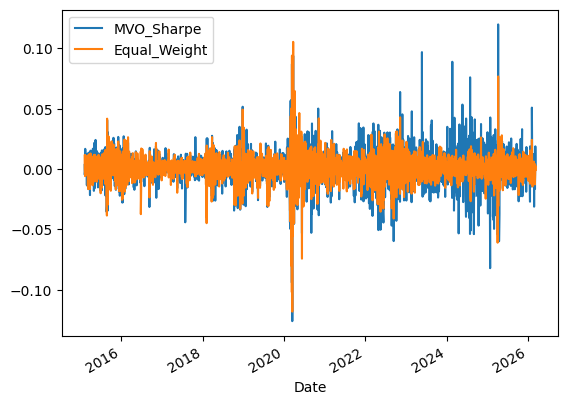

In [23]:
portf_returns_df.plot()

In [21]:
# Portfolio metrics
def calculate_performance_metrics(returns: pd.DataFrame) -> Dict[str, float]:
    risk_free_rate = 0.0  # Risk-free rate (e.g., 0 for simplicity)
    trading_days = 252    # Number of trading days in a year

    # Calculate Annualized Return
    annualized_return = (1 + returns.mean())**trading_days - 1

    # Calculate Annualized Volatility
    annualized_volatility = returns.std() * np.sqrt(trading_days)

    # Calculate Sharpe Ratio
    sharpe_ratio = (returns.mean() - risk_free_rate) / returns.std()
    sharpe_ratio *= np.sqrt(trading_days)  # Annualize Sharpe ratio

    # Calculate Maximum Drawdown
    def calculate_max_drawdown(returns):
        cumulative_returns = (1 + returns).cumprod()
        running_max = cumulative_returns.cummax()
        drawdown = (cumulative_returns - running_max) / running_max
        max_drawdown = drawdown.min()
        return max_drawdown

    max_drawdown = returns.apply(calculate_max_drawdown)

    return {
        'Annualized Return': annualized_return,
        'Annualized Volatility': annualized_volatility,
        'Sharpe Ratio': sharpe_ratio,
        'Maximum Drawdown': max_drawdown
    }

def print_table_performance_metrics(returns: pd.DataFrame):
    performance_table = pd.DataFrame(calculate_performance_metrics(returns))

    # Display the performance table
    performance_table_styled = performance_table.style.format("{:.2f}")
    display(performance_table_styled)

In [30]:
print_table_performance_metrics(portf_returns_df)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
MVO_Sharpe,0.28,0.23,1.04,-0.37
Equal_Weight,0.17,0.18,0.87,-0.36


Text(0.5, 0, 'Date')

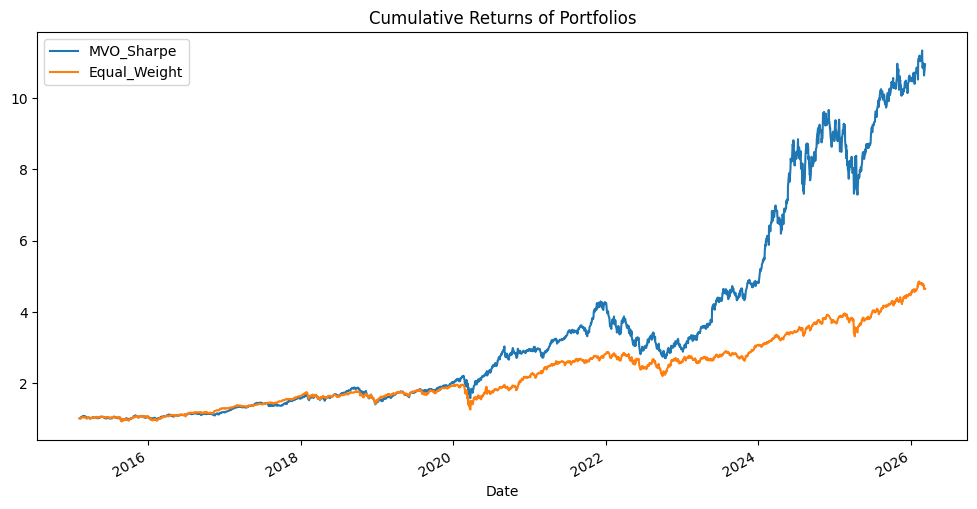

In [20]:
# Portfolio returns
# make a plot with the evolution over the years
 
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
for col in portf_returns_df.columns:
    (1 + portf_returns_df[col]).cumprod().plot(label=col)
plt.title("Cumulative Returns of Portfolios")
#legend
plt.legend()
plt.xlabel("Date")

### Concrete Example rolling vs expanding window

In [51]:
# Example rolling window
# Quick debug: Compare rolling vs expanding windows
import pandas as pd
import numpy as np

# Create sample data
np.random.seed(42)
dates = pd.date_range('2020-01-01', periods=20, freq='D')
returns = pd.DataFrame(np.random.randn(20, 3) * 0.01, index=dates, columns=['A', 'B', 'C'])

print("="*70)
print("SAMPLE DATA (20 days, 3 assets)")
print(f"Index: {returns.index[0]} → {returns.index[-1]}")
print("="*70)

lookback = 5
optimize_every = 5
T = len(returns)

print(f"\nParameters: lookback={lookback}, optimize_every={optimize_every}, T={T}\n")

# ─────────────────────────────────────────────────────────────────────
print("ROLLING WINDOW (Fixed size)")
print("─" * 70)
for t in range(lookback, T):
    if (t - lookback) % optimize_every == 0:
        # ROLLING: Always lookback periods
        train_start = t - lookback
        train_end = t
        train_data = returns.iloc[train_start:train_end]
        
        print(f"t={t:2d} | Reoptimize | Train window: [{train_start:2d}:{train_end:2d}] | "
              f"Length: {len(train_data):2d} | "
              f"Dates: {train_data.index[0].date()} → {train_data.index[-1].date()}")

# ─────────────────────────────────────────────────────────────────────
print("\n\nEXPANDING WINDOW (Growing size)")
print("─" * 70)
for t in range(lookback, T):
    if (t - lookback) % optimize_every == 0:
        # EXPANDING: From start to current t
        train_start = 0
        train_end = t
        train_data = returns.iloc[train_start:train_end]
        
        print(f"t={t:2d} | Reoptimize | Train window: [{train_start:2d}:{train_end:2d}] | "
              f"Length: {len(train_data):2d} | "
              f"Dates: {train_data.index[0].date()} → {train_data.index[-1].date()}")

# ─────────────────────────────────────────────────────────────────────
print("\n\nHYBRID WINDOW (Capped expanding)")
print("─" * 70)
cap = 2 * lookback  # Cap at 2x lookback

for t in range(lookback, T):
    if (t - lookback) % optimize_every == 0:
        # HYBRID: Expand but cap at max_window
        train_start = max(0, t - cap)
        train_end = t
        train_data = returns.iloc[train_start:train_end]
        
        print(f"t={t:2d} | Reoptimize | Train window: [{train_start:2d}:{train_end:2d}] | "
              f"Length: {len(train_data):2d} | "
              f"Dates: {train_data.index[0].date()} → {train_data.index[-1].date()}")

SAMPLE DATA (20 days, 3 assets)
Index: 2020-01-01 00:00:00 → 2020-01-20 00:00:00

Parameters: lookback=5, optimize_every=5, T=20

ROLLING WINDOW (Fixed size)
──────────────────────────────────────────────────────────────────────
t= 5 | Reoptimize | Train window: [ 0: 5] | Length:  5 | Dates: 2020-01-01 → 2020-01-05
t=10 | Reoptimize | Train window: [ 5:10] | Length:  5 | Dates: 2020-01-06 → 2020-01-10
t=15 | Reoptimize | Train window: [10:15] | Length:  5 | Dates: 2020-01-11 → 2020-01-15


EXPANDING WINDOW (Growing size)
──────────────────────────────────────────────────────────────────────
t= 5 | Reoptimize | Train window: [ 0: 5] | Length:  5 | Dates: 2020-01-01 → 2020-01-05
t=10 | Reoptimize | Train window: [ 0:10] | Length: 10 | Dates: 2020-01-01 → 2020-01-10
t=15 | Reoptimize | Train window: [ 0:15] | Length: 15 | Dates: 2020-01-01 → 2020-01-15


HYBRID WINDOW (Capped expanding)
──────────────────────────────────────────────────────────────────────
t= 5 | Reoptimize | Train window

## Incorporation of expanding window

In [35]:
from typing import Dict, Tuple, Callable
import numpy as np
import pandas as pd
from pypfopt.efficient_frontier import EfficientFrontier

# Current function to updrade

def backtest_exp_w(
    portfolio_funcs: Dict[str, Callable],
    prices: pd.DataFrame,
    lookback: int,
    optimize_every: int = 1,
    verbose: bool = True
) -> Tuple[pd.DataFrame, Dict[str, pd.DataFrame]]:
    """
    Walk-forward backtester for multiple portfolio strategies.
    
    Args:
        portfolio_funcs: Dict of {strategy_name: optimization_function}
        prices: DataFrame with asset prices (index=dates, columns=tickers)
        lookback: Training window size (in periods)
        optimize_every: Reoptimization frequency (in periods)
        verbose: Print progress
    
    Returns:
        Tuple of (portfolio_returns_df, weights_dict)
    """
    N = prices.shape[1]
    X = prices.pct_change().dropna()
    T = len(X)
    
    portf_rets = {}
    ws = {}

    for portfolio_name, portfolio_func in portfolio_funcs.items():
        if verbose:
            print(f"Backtesting portfolio: {portfolio_name}...")
            print(f"  Total periods: {T}, Lookback: {lookback}, OOS periods: {T - lookback}\n")

        # Initialize variables
        current_w = np.repeat(0, N)  # Start with zero weight (will be set at first optimization)
        w = pd.DataFrame(index=X.index, columns=X.columns, dtype=float)
        portf_ret = pd.Series(index=X.index,  dtype=float)
        portf_ret.name = portfolio_name

        for t in range(lookback, T):
            # Reoptimize portfolio if necessary
            if (t - lookback) % optimize_every == 0:
                    
                    train_data = X.iloc[0: t]
                    print(f"Reoptimizing lookback at t={t} ({X.index[t].date()})...")
                    # show min date and max date
                    print(f"  [DEBUG] Training data range: {train_data.index[0].date()} to {train_data.index[-1].date()}")
                    #print(f"  [DEBUG] Training data shape: {train_data.shape}")
                    new_w = portfolio_func(train_data)
                    current_w = new_w

            # Store weights
            w.iloc[t] = current_w

            # Calculate portfolio return for this period (before rebalancing)
            Portfolio_period_return = (X.iloc[t] * current_w).sum()
            portf_ret.iloc[t] = Portfolio_period_return  # Store in Series

            #if verbose:
               # row_date = X.index[t]
                #row_contrib = (X.iloc[t] * current_w)
                #print(f"  [DEBUG] OOS date: {row_date.date()}, return: {Portfolio_period_return:.6f}, n_assets: {len(current_w)}")
                #print(f"  [DEBUG] Top contributions:\n{row_contrib.sort_values(ascending=False).head(5)}")
                #print(f"  [DEBUG] Bottom contributions:\n{row_contrib.sort_values(ascending=True).head(5)}")


            # Update weights based on asset performance (drift)
            current_w = current_w * (1 + X.iloc[t])
            current_w = current_w / current_w.sum()

        # Keep a record (remove initial NaNs)
        portf_rets[portfolio_name] = portf_ret[lookback:]
        ws[portfolio_name] = w[lookback:]

    # Combine all portfolio returns into a single DataFrame
    portf_rets_df = pd.DataFrame(portf_rets)

    return portf_rets_df, ws




In [36]:
# Same inputs but dif backtest funct
# ── Run backtest ─────────────────────────────────────────────────────────────

# Use daily returns
lookback_days = round(0.5 * len(Daily_prices))  # First 50% as training window
print(f"Daily data: {len(Daily_prices)} trading days")
print(f"Lookback window: {lookback_days} days\n")


portfolio_functions = {
    'MVO_Sharpe':  mvo_optimizer,
    'Equal_Weight':  equal_weight_optimizer,
}

portf_returns_df, weights_dict = backtest_exp_w(
    portfolio_funcs=portfolio_functions,
    prices=Daily_prices,
    lookback=lookback_days,
   # rebalance_every=21,  # Monthly (≈21 trading days)
    optimize_every=63,   # Quarterly (≈63 trading days)
    #cost_bps=10,         # 10 basis points per transaction
    verbose=True
)

print("\n" + "="*70)
print(portf_returns_df.describe())

Daily data: 5582 trading days
Lookback window: 2791 days

Backtesting portfolio: MVO_Sharpe...
  Total periods: 5581, Lookback: 2791, OOS periods: 2790

Reoptimizing lookback at t=2791 (2015-02-05)...
  [DEBUG] Training data range: 2004-01-05 to 2015-02-04

  [DEBUG] Train returns shape: (2791, 41)
  [DEBUG] Annualized return: AA      0.037137
AAPL    0.589427
AIG     0.005379
AMGN    0.128651
AMZN    0.303725
AXP     0.158722
BA      0.190524
BAC     0.097302
C      -0.021713
CAT     0.149071
CSCO    0.066773
CVX     0.162860
DD      0.116515
DIS     0.199322
GE      0.056875
GS      0.149682
HD      0.175524
HON     0.173450
HPQ     0.117389
IBM     0.091162
INTC    0.077484
IP      0.138273
JNJ     0.107199
JPM     0.163802
KO      0.094342
MCD     0.182720
MMM     0.117074
MO      0.225910
MRK     0.105195
MSFT    0.107841
NKE     0.223981
NVDA    0.241106
PFE     0.059844
PG      0.096067
SHW     0.273589
T       0.126135
TRV     0.170148
UNH     0.198079
VZ      0.115309
WMT     

In [37]:
#Portfolio metrics
print_table_performance_metrics(portf_returns_df)

,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
MVO_Sharpe,0.22,0.21,0.95,-0.31
Equal_Weight,0.17,0.18,0.87,-0.36
